<a href="https://colab.research.google.com/github/Amruth-U-tech/DL-Journey/blob/main/07-Auto-Encoders/AutoEncoders-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def map_image(image, label):
    image = tf.cast(image, tf.float32)
    image = image/255.0
    return image, image

In [5]:
batch_size = 128
shuffle_buffer_size = 1024

train_dataset = tfds.load('fashion_mnist',as_supervised=True, split="train")
train_dataset = train_dataset.map(map_image)

train_dataset = train_dataset.shuffle(shuffle_buffer_size).batch(batch_size).repeat()

test_dataset = tfds.load('fashion_mnist',as_supervised=True, split="test")
test_dataset = test_dataset.map(map_image)
test_dataset = test_dataset.batch(batch_size).repeat()

In [7]:
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D

def conv_autoencoder(inputs):
  enc_conv1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
  enc_pool1 = MaxPooling2D((2, 2), padding='same')(enc_conv1)

  enc_conv2 = Conv2D(128, (3, 3), activation='relu', padding='same')(enc_pool1)
  enc_pool2 = MaxPooling2D((2, 2), padding='same')(enc_conv2)

  latent = Conv2D(256, (3, 3), activation='relu', padding='same')(enc_pool2)

  dec_up1 = UpSampling2D((2, 2))(latent)
  dec_conv1 = Conv2D(128, (3, 3), activation='relu', padding='same')(dec_up1)

  dec_up2 = UpSampling2D((2, 2))(dec_conv1)
  dec_conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(dec_up2)

  recontruction = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(dec_conv2)

  return latent,recontruction

In [8]:
def build_model():
  inputs = Input(shape=(28, 28, 1))
  latent_output,reconstruction_output = conv_autoencoder(inputs)

  autoencoder_model = tf.keras.Model(inputs, reconstruction_output,name = "conv_autoencoder")
  encoder_model = tf.keras.Model(inputs, latent_output,name = "encoder_model")

  return autoencoder_model,encoder_model

autoencoder_model,encoder_model = build_model()

In [9]:
autoencoder_model.summary()
encoder_model.summary()

Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739,073 (2.82 MB)

 Trainable params: 739,073 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

Model: "encoder_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369,664 (1.41 MB)

 Trainable params: 369,664 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
train_steps = 60000//batch_size
valid_steps = 60000//batch_size

autoencoder_model.compile(optimizer='adam', loss='binary_crossentropy')

conv_model_history = autoencoder_model.fit(train_dataset,steps_per_epoch=train_steps,validation_data=test_dataset,validation_steps=valid_steps,epochs=1)


468/468 ━━━━━━━━━━━━━━━━━━━━ 1309s 3s/step - loss: 0.2920 - val_loss: 0.2664


In [12]:
def display_one_row(disp_images,offset,shape=(28,28)):
  for idx, test_image in enumerate(disp_images):
    plt.subplot(3,10,offset+idx+1)

    plt.xticks([])
    plt.yticks([])
    test_datasetimage = np.reshape(test_image,shape)
    plt.imshow(test_image, cmap='gray')




def display_results(disp_input_images,encoded_images,decoded_images,enc_shape=(7,7)):
  plt.figure(figsize=(16, 4))
  display_one_row(disp_input_images,0,shape=(28,28))
  display_one_row(encoded_images,10,shape=enc_shape)
  display_one_row(decoded_images,20,shape=(28,28))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


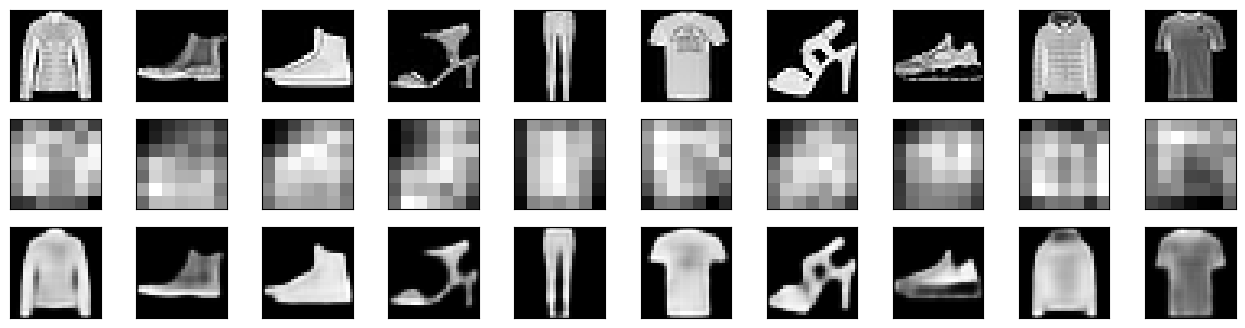

In [14]:
test_dataset  = test_dataset.take(1)

output_samples = []
for input_image,image in tfds.as_numpy(test_dataset):
  output_samples = input_image

idxs = np.array([1,2,3,4,5,6,7,8,9,10])

conv_output_samples = np.array(output_samples[idxs])
conv_output_samples = np.reshape(conv_output_samples, (10,28,28,1))

encoded = encoder_model.predict(conv_output_samples)
encoded_for_display = np.mean(encoded,axis=-1)

predicted = autoencoder_model.predict(conv_output_samples)

display_results(conv_output_samples,encoded_for_display,predicted,enc_shape=(7,7))